In [1]:
# Imports and defaults
import joblib
from joblib import Parallel, delayed
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linprog
import time

mpl.style.use("classic")
mpl.rcParams["figure.figsize"] = [6, 4]

mpl.rcParams["axes.linewidth"] = 0.75
mpl.rcParams["errorbar.capsize"] = 3
mpl.rcParams["figure.facecolor"] = "w"
mpl.rcParams["grid.linewidth"] = 0.75
mpl.rcParams["lines.linewidth"] = 0.75
mpl.rcParams["patch.linewidth"] = 0.75
mpl.rcParams["xtick.major.size"] = 3
mpl.rcParams["ytick.major.size"] = 3

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.size"] = 10
mpl.rcParams["axes.titlesize"] = "medium"
mpl.rcParams["legend.fontsize"] = "medium"

import platform
print("python %s" % platform.python_version())
print("matplotlib %s" % mpl.__version__)
print("%d joblib CPUs" % joblib.cpu_count())

def linestyle2dashes(style):
  if style == "--":
    return (3, 3)
  elif style == ":":
    return (0.5, 2.5)
  else:
    return (None, None)

python 3.12.2
matplotlib 3.9.2
16 joblib CPUs


Number of arms: 1017
Percentage of invalid rewards: 2.56%


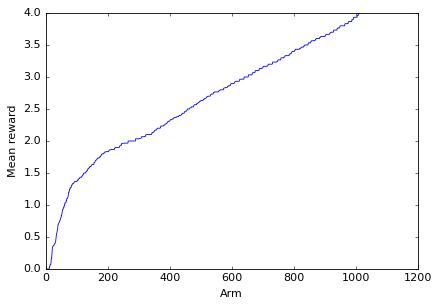

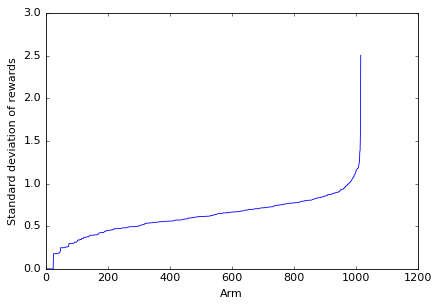

Running Uniform...
..................................................
Running Variance...
..................................................
Running UCB...
..................................................


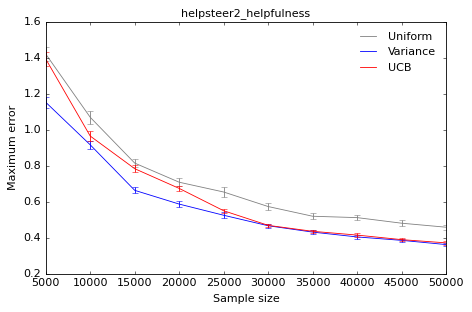

In [2]:
filename = "helpsteer2_helpfulness"

with open("%s.jsonl" % filename, "r") as f:
  data = f.readlines()
data = [json.loads(_) for _ in data]

per_arm_rewards = 30  # number of per-arm random rewards
K = len(data) // per_arm_rewards  # number of arms
print("Number of arms: %d" % K)

rewards = np.asarray([_["predicted_score"] for _ in data], dtype=float)
print("Percentage of invalid rewards: %.2f%%" % (100 * (rewards == -1).mean()))

random_rewards = {}
mu = np.zeros(K)
sigma = np.zeros(K)
for i in range(K):
  sub_rewards = rewards[i * per_arm_rewards : (i + 1) * per_arm_rewards]
  sub_rewards = sub_rewards[sub_rewards >= 0]  # eliminate invalid rewards
  random_rewards[i] = sub_rewards
  mu[i] = sub_rewards.mean()
  sigma[i] = np.maximum(sub_rewards.std(), 1e-3)

plt.plot(np.sort(mu))
plt.xlabel("Arm")
plt.ylabel("Mean reward")
plt.show()

plt.plot(np.sort(sigma))
plt.xlabel("Arm")
plt.ylabel("Standard deviation of rewards")
plt.show()

n = 50000  # number of logged steps
num_runs = 50  # number of runs

# algorithms
algs = [
  (0, "Uniform", "gray", "Uniform"),
  (1, "Variance", "blue", "Variance"),
  (2, "UCB", "red", "UCB")]

for alg in algs:
  alg_name = alg[1]
  print("Running %s..." % alg_name)

  # initialize reward variances
  if alg_name == "Uniform":
    sigma2 = np.ones(K)
  elif alg_name == "Variance":
    sigma2 = np.square(sigma)
  elif alg_name == "UCB":
    sigma2 = - np.ones(K)
  else:
    raise Exception("Unknown algorithm!")

  steps = np.arange(n // 10, n + 1, n // 10)
  errors = np.zeros((steps.size, num_runs))
  for run in range(num_runs):
    print(".", end="")

    # bandit algorithm statistics
    delta = 0.01
    pulls = np.zeros(K)  # number of pulls
    sum_reward = np.zeros(K)  # sum of rewards of pulled arms
    sum_reward2 = np.zeros(K)  # sum of squared rewards of pulled arms

    # data logging
    logged_arms = np.zeros(n)  # logged arms
    logged_rewards = np.zeros(n)  # logged rewards
    for t in range(n):
      # pull arm
      if (alg_name == "UCB") and (np.floor(t / K) <= 4 * np.log(1 / delta)):
        arm = t % K
      else:
        ucb = sigma2 / np.maximum(pulls, 1e-6)
        arm = np.argmax(ucb)

      # observe random reward
      r = random_rewards[arm][np.random.randint(random_rewards[arm].size)]

      # logging
      logged_arms[t] = arm
      logged_rewards[t] = r

      # update statistics 
      pulls[arm] += 1
      sum_reward[arm] += r
      sum_reward2[arm] += r * r
      if (alg_name == "UCB") and (np.floor(t / K) > 4 * np.log(1 / delta)):
        mu_hat = sum_reward / pulls
        var_hat = (sum_reward2 - 2 * sum_reward * mu_hat + pulls * np.square(mu_hat)) / (pulls - 1)
        sigma2 = var_hat / (1 - 2 * np.sqrt(np.log(1 / delta) / pulls))

    # estimate mean arm rewards from logged data
    for ndx, t in enumerate(steps):
      mu_hat = np.zeros(K)
      for i in range(K):
        sub = np.logical_and(logged_arms == i, np.arange(n) < t)
        mu_hat[i] = logged_rewards[sub].sum() / np.sum(sub)
      errors[ndx, run] = np.abs(mu - mu_hat).max()
  print()

  plt.plot(steps, errors.mean(axis=-1), color=alg[2], label=alg[3])
  plt.errorbar(steps, errors.mean(axis=-1), errors.std(axis=-1) / np.sqrt(num_runs),
    fmt="none", ecolor=alg[2])

plt.title(filename)
plt.xlabel("Sample size")
plt.ylabel("Maximum error")
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("Error.pdf", format="pdf", dpi=1200, bbox_inches=0)
plt.show()